In [1]:
# filter out warnings
import warnings
warnings.filterwarnings("ignore")

# disable wandb
import os 
os.environ["WANDB_DISABLED"] = "true"

## Fine-tune with real data
Here we load a pretrained model through transformers interface (Hugging Face).
Load the `human_enhancers_cohn` dataset from Genomic Benchmarks datasets and fine-tune the tiny HyenaDNA model. 
Finally, we eval the fine-tuned model on a subset of the test split and plot the confusion matrix.


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import TrainingArguments, Trainer, logging
import torch
from datasets import Dataset

# list of HyenaDNA pretrained models available in the hugging face hub
pretrained_models_max_length = {
    'hyenadna-tiny-1k-seqlen-hf': 1024,
        'hyenadna-small-32k-seqlen-hf': 32768,
        'hyenadna-medium-160k-seqlen-hf': 160000,
        'hyenadna-medium-450k-seqlen-hf': 450000,  # T4 up to here
        'hyenadna-large-1m-seqlen-hf': 1_000_000,
}
pretrained_model_name = 'hyenadna-tiny-1k-seqlen-hf'

# instantiate pretrained model
checkpoint = 'LongSafari/'+pretrained_model_name
model_max_length = pretrained_models_max_length[pretrained_model_name]

# bfloat16 for better speed and reduced memory usage
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True,)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, torch_dtype=torch.bfloat16, device_map="auto", trust_remote_code=True)

Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a configuration with custom code to ensure no malicious code has been contributed in a newer revision.
Explicitly passing a `revision` is encouraged when loading a model with custom code to ensure no malicious code has been contributed in a newer revision.
Some weights of the model checkpoint at LongSafari/hyenadna-tiny-1k-seqlen-hf were not used when initializing HyenaDNAForSequenceClassification: ['lm_head.weight']
- This IS expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing HyenaDNAForSequenceClassification from the checkpoint of a model th

In [3]:
# experiment settings:
num_epochs = 100  # ~100 seems fine
max_length = 500  # max len of sequence of dataset (of what you want)
use_padding = True
dataset_path = 'data/genomic_benchmarks'
dataset_name = 'human_enhancers_cohn'
batch_size = 256
learning_rate = 6e-4  # good default for Hyena
rc_aug = True  # reverse complement augmentation
add_eos = False  # add end of sentence token
weight_decay = 0.1

In [4]:
from src.dataloaders.datasets.genomic_bench_dataset import GenomicBenchmarkDataset

# create a dataset
ds_train = GenomicBenchmarkDataset(
        max_length = max_length,
        use_padding = use_padding,
        split = 'train',
        tokenizer=tokenizer,
        dest_path=dataset_path,
        dataset_name=dataset_name,
        rc_aug=rc_aug,
        add_eos=add_eos,
    )

ds_test = GenomicBenchmarkDataset(
        max_length = max_length,
        use_padding = use_padding,
        split = 'test',
        tokenizer=tokenizer,
        dest_path=dataset_path,
        dataset_name=dataset_name,
        rc_aug=rc_aug,
        add_eos=add_eos,
    )

already downloaded train-human_enhancers_cohn
already downloaded test-human_enhancers_cohn


In [37]:
# load the dataset
# Dataset.from_dict expects input_ids as a nested list with size [batch, seq_len] 
# and labels as a list with size [batch]
data_train = []
labels_train = []
for _, (d, l) in enumerate(ds_train):
    data_train.append(d.tolist())
    labels_train.append(l.item())

DS_train = Dataset.from_dict({"input_ids": data_train, "labels": labels_train})
DS_train.set_format('pt')

data_test = []
labels_test = []
for _, (d, l) in enumerate(ds_test):
    data_test.append(d.tolist())
    labels_test.append(l.item())

DS_test = Dataset.from_dict({"input_ids": data_test, "labels": labels_test})
DS_test.set_format('pt')

print(f"Train dataset shape:[{len(data_train)},{len(data_train[0])}]")
print(f"Train labels shape:[{len(labels_train)}]")  

print(f"Test dataset shape:[{len(data_test)},{len(data_test[0])}]")
print(f"Test labels shape:[{len(labels_test)}]")  

Train dataset shape:[20843,500]
Train labels shape:[20843]
Test dataset shape:[6948,500]
Test labels shape:[6948]


In [38]:
# Initialize Trainer
# Note that we're using extremely small batch sizes to maximize
# our ability to fit long sequences in memory!
args = {
    "output_dir": "tmp",
    "num_train_epochs": 5,
    "per_device_train_batch_size": 1,
    "gradient_accumulation_steps": 4,
    # "gradient_checkpointing": True,
    "learning_rate": 2e-5,
}
training_args = TrainingArguments(**args)

trainer = Trainer(model=model, args=training_args, train_dataset=DS_train)
result = trainer.train()

print(result)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
***** Running training *****
  Num examples = 20843
  Num Epochs = 5
  Instantaneous batch size per device = 1
  Total train batch size (w. parallel, distributed & accumulation) = 4
  Gradient Accumulation steps = 4
  Total optimization steps = 26050
  Number of trainable parameters = 436352
  2%|▏         | 500/26050 [00:32<25:19, 16.82it/s]Saving model checkpoint to tmp/checkpoint-500
Configuration saved in tmp/checkpoint-500/config.json
Model weights saved in tmp/checkpoint-500/pytorch_model.bin
  2%|▏         | 501/26050 [00:32<29:02, 14.66it/s]

{'loss': 0.6853, 'learning_rate': 1.961612284069098e-05, 'epoch': 0.1}


  4%|▍         | 1000/26050 [01:03<23:57, 17.43it/s]Saving model checkpoint to tmp/checkpoint-1000
Configuration saved in tmp/checkpoint-1000/config.json
Model weights saved in tmp/checkpoint-1000/pytorch_model.bin
  4%|▍         | 1001/26050 [01:03<26:32, 15.73it/s]

{'loss': 0.6787, 'learning_rate': 1.923224568138196e-05, 'epoch': 0.19}


  6%|▌         | 1500/26050 [01:34<23:53, 17.13it/s]Saving model checkpoint to tmp/checkpoint-1500
Configuration saved in tmp/checkpoint-1500/config.json
Model weights saved in tmp/checkpoint-1500/pytorch_model.bin


...

{'loss': 0.6593, 'learning_rate': 4.2226487523992327e-07, 'epoch': 4.89}


100%|█████████▉| 26000/26050 [26:13<00:03, 16.14it/s]Saving model checkpoint to tmp/checkpoint-26000
Configuration saved in tmp/checkpoint-26000/config.json
Model weights saved in tmp/checkpoint-26000/pytorch_model.bin
100%|█████████▉| 26002/26050 [26:13<00:03, 15.32it/s]

{'loss': 0.6648, 'learning_rate': 3.838771593090211e-08, 'epoch': 4.99}


100%|██████████| 26050/26050 [26:16<00:00, 16.90it/s]

Training completed. Do not forget to share your model on huggingface.co/models =)


100%|██████████| 26050/26050 [26:16<00:00, 16.53it/s]

{'train_runtime': 1576.1036, 'train_samples_per_second': 66.122, 'train_steps_per_second': 16.528, 'train_loss': 0.6640267926763436, 'epoch': 5.0}
TrainOutput(global_step=26050, training_loss=0.6640267926763436, metrics={'train_runtime': 1576.1036, 'train_samples_per_second': 66.122, 'train_steps_per_second': 16.528, 'train_loss': 0.6640267926763436, 'epoch': 5.0})


In [39]:
import torch

# Verifica si hay una GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


In [42]:
import numpy as np

# Get a sample of test data
np.random.seed(42)
idx = np.random.randint(0, len(DS_test), 100)

data, target = DS_test["input_ids"][idx], DS_test["labels"][idx]
data, target = data.to(device), target.to(device)

# Set the model to evaluation mode and disable gradient computation
model.eval()
with torch.no_grad():
    output = model(data)
    
def loss_fn(output, target):
    return torch.nn.functional.cross_entropy(output, target)

# Calculate the loss
loss = loss_fn(output["logits"], target.squeeze())

# Get the predicted class
pred = output["logits"].argmax(dim=1, keepdim=True)

# Calculate accuracy
correct = pred.eq(target.view_as(pred)).sum().item()
accuracy = 100. * correct / len(target)

print(f'Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%')

Loss: 0.6602, Accuracy: 67.00%


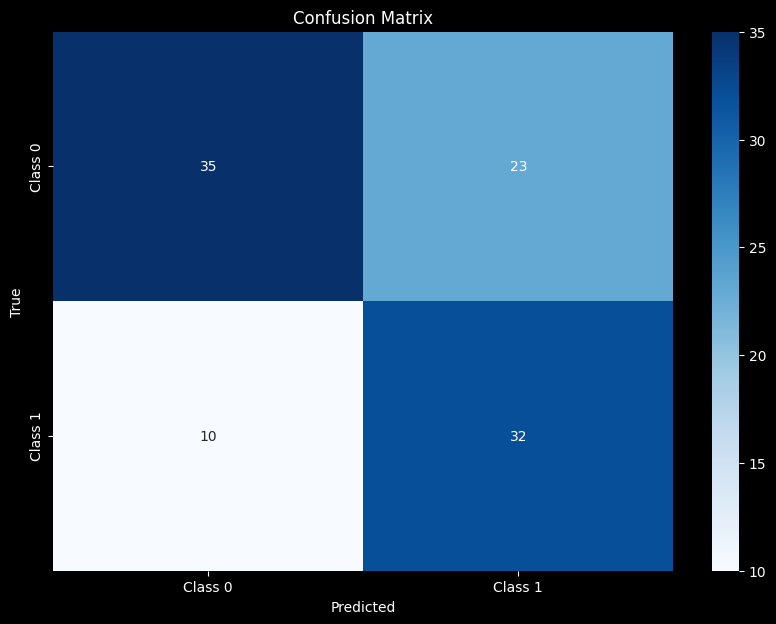

In [43]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

# Convert tensors to numpy arrays
pred_np = pred.cpu().numpy()
target_np = target.cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(target_np, pred_np)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()